In [2]:
import numpy as np
import nibabel as nib
import pandas as pd
from scipy.signal import convolve
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix

# ── 0. Parameters ─────────────────────────────────────────────────────────────
TR          = 2.0
N_VOXELS    = 5
NOISE_STD   = 1.0
subject     = 'sub-002'
import os
results_dir = "rsa_results"

In [3]:
def get_scan_start_time(log_path):
    """
    Extract time of first scanner TTL pulse from PsychoPy log.
    This is t=0 for the GLM — all onsets must be relative to this.
    """
    with open(log_path, 'r') as f:
        for line in f:
            if 'Keypress: equal' in line:
                return float(line.split('\t')[0])
    raise ValueError(f"No scanner TTL found in {log_path}")


def build_stimulus_events(behavioral_csv_path, log_path, stim_duration=1.0):
    """
    Convert trial-level CSV → stimulus-level events dataframe for nilearn GLM.
    
    Each stimulus presentation becomes one row with:
        onset      : time relative to first TR (seconds)
        duration   : stimulus display duration (seconds)
        trial_type : '{shape}_{role}_{phase}' or '{shape}_{role}_{phase}_{trial_type}'
    
    Parameters
    ----------
    behavioral_csv_path : str
    log_path            : str  - PsychoPy .log file for scan start time
    stim_duration       : float - assumed display duration per stimulus (~1s from your design)
    """
    df = pd.read_csv(behavioral_csv_path)
    df_main = df[df['block'].str.startswith('main')].copy()
    
    scan_t0 = get_scan_start_time(log_path)
    print(f"Scan start time (t0): {scan_t0:.3f}s")
    
    rows = []
    
    for _, trial in df_main.iterrows():
        trial_type = trial['trial_type']   # 'ABA' or 'ABB'
        A  = trial['A_stim']
        B  = trial['B_stim']
        Ap = trial['A_prime']
        Bp = trial['B_prime']
        
        # --- Rule phase ---
        # rule3 role is determined by trial_type: A if ABA, B if ABB
        rule_presentations = [
            (trial['t_rule1'],  A,                             'A',      'rule1'),
            (trial['t_rule2'],  B,                             'B',      'rule2'),
            (trial['t_rule3'],  A if trial_type=='ABA' else B,
                                'A' if trial_type=='ABA' else 'B', 'rule3'),
        ]
        for t, shape, role, phase in rule_presentations:
            rows.append({
                'onset':      t - scan_t0,
                'duration':   stim_duration,
                'trial_type': f'{shape}_{role}_{phase}'
            })
        
        # --- Test phase — further split by trial_type ---
        test_presentations = [
            (trial['t_test1'], Ap, 'Aprime', 'test1'),
            (trial['t_test2'], Bp, 'Bprime', 'test2'),
        ]
        for t, shape, role, phase in test_presentations:
            rows.append({
                'onset':      t - scan_t0,
                'duration':   stim_duration,
                'trial_type': f'{shape}_{role}_{phase}_{trial_type}'
            })
    
    events_df = (pd.DataFrame(rows)
                   .sort_values('onset')
                   .reset_index(drop=True))
    
    # Sanity check
    print(f"\nCondition counts:")
    print(events_df['trial_type'].value_counts().sort_index())
    print(f"\nTotal events: {len(events_df)}")
    print(f"Unique conditions: {events_df['trial_type'].nunique()}")
    
    return events_df

In [4]:
# behavioral_csv = '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99.csv'
behavioral_csv = '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99_with_t_fixation_renamed_to_onset.csv'
real_bold_path ='/usr/people/gw0402/pygers_workshop/sample_study/data/bids/derivatives/fmriprep/sub-002/ses-01/func/sub-002_ses-01_task-perceptXbind_run-1_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz' 
log_file = '/usr/people/gw0402/NEU502B/brain-binding/data/2026-03-02_16-25-49/7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99.log'

In [21]:
events_df

,block,sid,trial,sample_stim,isi_condition,trial_type,A_stim,B_stim,A_prime,B_prime,...,onset,t_sample,t_delay,t_rule1,t_rule2,t_rule3,t_test1,t_test2,t_response,duration
0,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,0,triangle,1.0,NaN,NaN,NaN,NaN,NaN,...,120.544442,121.064368,121.579318,NaN,NaN,NaN,NaN,NaN,122.612704,2.068262
1,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,1,star,2.5,NaN,NaN,NaN,NaN,NaN,...,123.143501,123.662640,124.178630,NaN,NaN,NaN,NaN,NaN,126.713441,3.569940
2,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,2,rectangle,1.0,NaN,NaN,NaN,NaN,NaN,...,127.262468,127.779267,128.296155,NaN,NaN,NaN,NaN,NaN,129.312179,2.049711
3,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,3,rectangle,2.5,NaN,NaN,NaN,NaN,NaN,...,129.993111,130.512444,131.029092,NaN,NaN,NaN,NaN,NaN,133.545812,3.552701
4,WM,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,4,circle,2.5,NaN,NaN,NaN,NaN,NaN,...,134.392979,134.913506,135.429198,NaN,NaN,NaN,NaN,NaN,137.945691,3.552711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,115,NaN,NaN,ABB,rectangle,triangle,rectangle,circle,...,1643.647853,NaN,NaN,1644.165795,1645.414853,1646.964339,1648.315249,1649.866174,1651.548324,7.900471
140,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,116,NaN,NaN,ABB,star,rectangle,star,triangle,...,1654.116019,NaN,NaN,1654.631534,1655.815157,1657.381713,1659.098501,1660.848905,1662.348662,8.232643
141,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,117,NaN,NaN,ABA,circle,triangle,rectangle,triangle,...,1665.831862,NaN,NaN,1666.347808,1667.881652,1669.681030,1671.548589,1672.864219,1674.015176,8.183314
142,main_run4,7ea7ce2b-65c3-4ff4-a9bd-ded1149f0b99,118,NaN,NaN,ABB,circle,star,circle,star,...,1680.065587,NaN,NaN,1680.582131,1682.198637,1683.580953,1685.398516,1687.015817,1688.280926,8.215339


In [5]:
# ── 1. Load real events to mirror exact trial sequence ────────────────────────
events_df = pd.read_csv(behavioral_csv)

# Use your build_stimulus_events function to get the same events
# you used in the real GLM
real_events = build_stimulus_events(
    behavioral_csv_path = behavioral_csv,
    log_path            = log_file,
    stim_duration       = 1.0
)

# Get scan duration from real BOLD
real_bold = nib.load(real_bold_path)
n_trs     = real_bold.shape[-1]
scan_duration = n_trs * TR

print(f"N TRs: {n_trs}, scan duration: {scan_duration:.1f}s")
print(f"N events: {len(real_events)}, N conditions: {real_events['trial_type'].nunique()}")

Scan start time (t0): 120.525s

Condition counts:
trial_type
circle_A_rule1                30
circle_A_rule3                15
circle_Aprime_test1_ABA       10
circle_Aprime_test1_ABB       20
circle_B_rule2                30
circle_B_rule3                15
circle_Bprime_test2_ABA       15
circle_Bprime_test2_ABB       17
rectangle_A_rule1             30
rectangle_A_rule3             15
rectangle_Aprime_test1_ABA    18
rectangle_Aprime_test1_ABB    11
rectangle_B_rule2             30
rectangle_B_rule3             15
rectangle_Bprime_test2_ABA    16
rectangle_Bprime_test2_ABB    17
star_A_rule1                  30
star_A_rule3                  15
star_Aprime_test1_ABA         15
star_Aprime_test1_ABB         18
star_B_rule2                  30
star_B_rule3                  15
star_Bprime_test2_ABA         13
star_Bprime_test2_ABB         12
triangle_A_rule1              30
triangle_A_rule3              15
triangle_Aprime_test1_ABA     17
triangle_Aprime_test1_ABB     11
triangle_B_rule

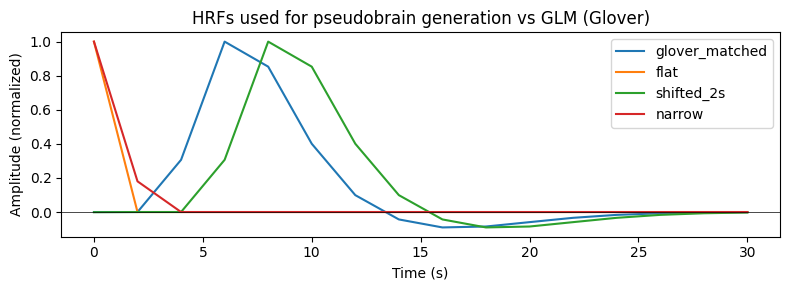

In [6]:
# ── 2. Define HRFs ────────────────────────────────────────────────────────────
# We will generate data with one HRF but fit GLM with another (Glover)
# to test whether mismatch alone produces the RDM pattern

t_hrf = np.arange(0, 32, TR)   # HRF time axis in TR units

def glover_hrf(t):
    """Canonical Glover (SPM) double-gamma HRF."""
    from nilearn.glm.first_level import spm_hrf
    return spm_hrf(TR, oversampling=1)[:len(t)]

def flat_hrf(t):
    """Flat/boxcar — stimulus duration only, no hemodynamic shape."""
    h = np.zeros(len(t))
    h[0] = 1.0
    return h

def shifted_hrf(t, delay=2.0):
    """Glover HRF shifted by `delay` seconds — simulates HRF peak mismatch."""
    from nilearn.glm.first_level import spm_hrf
    h = spm_hrf(TR, oversampling=1)[:len(t)]
    shift = int(delay / TR)
    return np.roll(h, shift)

def narrow_hrf(t):
    """Faster/narrower HRF — simulates subcortical or early visual timing."""
    h = np.exp(-t / 2.0) - 0.35 * np.exp(-t / 6.0)
    h = np.clip(h, 0, None)
    return h / h.max()

hrfs = {
    'glover_matched':   glover_hrf(t_hrf),      # no mismatch — null condition
    'flat':             flat_hrf(t_hrf),          # maximally mismatched
    'shifted_2s':       shifted_hrf(t_hrf, 2.0), # 2s delay mismatch
    'narrow':           narrow_hrf(t_hrf),        # shape mismatch
}

# Plot HRFs
fig, ax = plt.subplots(figsize=(8, 3))
for name, h in hrfs.items():
    ax.plot(t_hrf, h / h.max(), label=name)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (normalized)')
ax.set_title('HRFs used for pseudobrain generation vs GLM (Glover)')
ax.legend(); ax.axhline(0, color='k', linewidth=0.5)
plt.tight_layout(); plt.show()

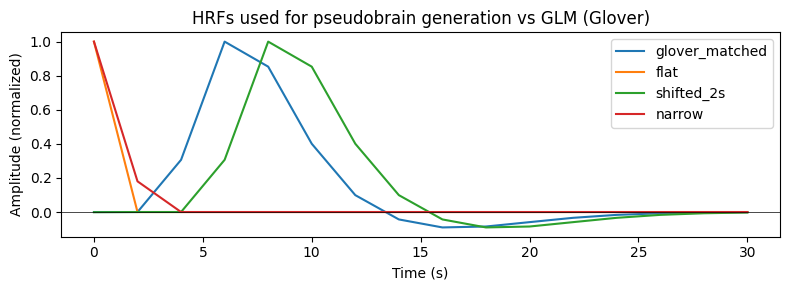

In [7]:
# ── 2. Define HRFs ────────────────────────────────────────────────────────────
# We will generate data with one HRF but fit GLM with another (Glover)
# to test whether mismatch alone produces the RDM pattern

t_hrf = np.arange(0, 32, TR)   # HRF time axis in TR units

def glover_hrf(t):
    """Canonical Glover (SPM) double-gamma HRF."""
    from nilearn.glm.first_level import spm_hrf
    return spm_hrf(TR, oversampling=1)[:len(t)]

def flat_hrf(t):
    """Flat/boxcar — stimulus duration only, no hemodynamic shape."""
    h = np.zeros(len(t))
    h[0] = 1.0
    return h

def shifted_hrf(t, delay=2.0):
    """Glover HRF shifted by `delay` seconds — simulates HRF peak mismatch."""
    from nilearn.glm.first_level import spm_hrf
    h = spm_hrf(TR, oversampling=1)[:len(t)]
    shift = int(delay / TR)
    return np.roll(h, shift)

def narrow_hrf(t):
    """Faster/narrower HRF — simulates subcortical or early visual timing."""
    h = np.exp(-t / 2.0) - 0.35 * np.exp(-t / 6.0)
    h = np.clip(h, 0, None)
    return h / h.max()

hrfs = {
    'glover_matched':   glover_hrf(t_hrf),      # no mismatch — null condition
    'flat':             flat_hrf(t_hrf),          # maximally mismatched
    'shifted_2s':       shifted_hrf(t_hrf, 2.0), # 2s delay mismatch
    'narrow':           narrow_hrf(t_hrf),        # shape mismatch
}

# Plot HRFs
fig, ax = plt.subplots(figsize=(8, 3))
for name, h in hrfs.items():
    ax.plot(t_hrf, h / h.max(), label=name)
ax.set_xlabel('Time (s)'); ax.set_ylabel('Amplitude (normalized)')
ax.set_title('HRFs used for pseudobrain generation vs GLM (Glover)')
ax.legend(); ax.axhline(0, color='k', linewidth=0.5)
plt.tight_layout(); plt.show()

In [8]:
# ── 3. Build stimulus timeseries at TR resolution ─────────────────────────────
# One binary timeseries per condition: 1 at TRs where that stimulus appeared

tr_times    = np.arange(n_trs) * TR   # (n_trs,)
conditions  = sorted(real_events['trial_type'].unique())
n_cond      = len(conditions)

# Neural timeseries per condition: delta function at stimulus onset
stim_ts = np.zeros((n_cond, n_trs))
for c_idx, cond in enumerate(conditions):
    onsets = real_events[real_events['trial_type'] == cond]['onset'].values
    for onset in onsets:
        tr_idx = int(np.round(onset / TR))
        if 0 <= tr_idx < n_trs:
            stim_ts[c_idx, tr_idx] = 1.0

print(f"Stimulus timeseries shape: {stim_ts.shape}")
print(f"Total events encoded: {stim_ts.sum():.0f} (expected ~{len(real_events)})")

Stimulus timeseries shape: (32, 797)
Total events encoded: 600 (expected ~600)


In [9]:
# ── 4. Generate pseudobrain for each HRF ──────────────────────────────────────
# Each voxel: independent noise + equal response to ALL conditions
# (no selectivity — null model)

def generate_pseudobrain(stim_ts, hrf, n_voxels, noise_std, n_trs, tr):
    """
    Generate fake BOLD data with no condition selectivity.
    Every voxel responds equally to every stimulus, convolved with hrf.
    Pure noise otherwise.
    
    Returns: bold (n_trs, n_voxels)
    """
    # Sum all condition timeseries → one "any stimulus" timeseries
    any_stim = stim_ts.sum(axis=0)   # (n_trs,)
    
    # Convolve with HRF
    hrf_padded = np.zeros(n_trs)
    hrf_padded[:len(hrf)] = hrf
    bold_signal = np.real(np.fft.ifft(
        np.fft.fft(any_stim) * np.fft.fft(hrf_padded)
    ))                                # (n_trs,) — convolved signal
    
    # Each voxel: same signal + independent noise
    noise = np.random.randn(n_trs, n_voxels) * noise_std
    bold  = bold_signal[:, np.newaxis] + noise   # (n_trs, n_voxels)
    return bold

np.random.seed(42)
pseudobrains = {}
for hrf_name, hrf in hrfs.items():
    pseudobrains[hrf_name] = generate_pseudobrain(
        stim_ts, hrf, N_VOXELS, NOISE_STD, n_trs, TR
    )
    print(f"Generated pseudobrain [{hrf_name}]: shape={pseudobrains[hrf_name].shape}")

Generated pseudobrain [glover_matched]: shape=(797, 5)
Generated pseudobrain [flat]: shape=(797, 5)
Generated pseudobrain [shifted_2s]: shape=(797, 5)
Generated pseudobrain [narrow]: shape=(797, 5)


In [10]:
# ── 5. Wrap pseudobrain as NIfTI (1×1×N_VOXELS×n_trs) ────────────────────────
def bold_to_nifti(bold, tr):
    """bold: (n_trs, n_voxels) → NIfTI (1, 1, n_voxels, n_trs)"""
    data   = bold.T[np.newaxis, np.newaxis, :, :]   # (1, 1, n_voxels, n_trs)
    affine = np.eye(4) * 2                           # 2mm voxels, arbitrary
    affine[3, 3] = 1
    img    = nib.Nifti1Image(data.astype(np.float32), affine)
    # Set TR in header
    img.header.set_zooms((2, 2, 2, tr))
    return img

pseudo_niftis = {name: bold_to_nifti(bold, TR)
                 for name, bold in pseudobrains.items()}

In [11]:
# ── 6. Fit first-level GLM — identical to real pipeline ──────────────────────
# Using Glover HRF regardless of which HRF generated the data

def fit_glm_pseudobrain(bold_img, real_events, n_trs, tr):
    """Fit GLM with Glover HRF — same as real pipeline."""
    mask = nib.Nifti1Image(
        np.ones(bold_img.shape[:3], dtype=np.int8), bold_img.affine
    )
    model = FirstLevelModel(
        t_r            = tr,
        hrf_model      = 'glover',
        mask_img       = mask,
        smoothing_fwhm = None,
        standardize    = 'zscore_sample',
        signal_scaling = False,
        drift_model    = None,
        minimize_memory= False
    )
    
    TR_array      = np.arange(n_trs) * tr
    design_matrix = make_first_level_design_matrix(
        TR_array, real_events,
        hrf_model   = 'glover',
        drift_model = None
        # No confounds — pseudobrain has none
    )
    
    model.fit([bold_img], design_matrices=[design_matrix])
    return model, design_matrix

fitted_models = {}
design_mats   = {}
for hrf_name, pseudo_nifti in pseudo_niftis.items():
    print(f"Fitting GLM for [{hrf_name}] ...")
    fitted_models[hrf_name], design_mats[hrf_name] = fit_glm_pseudobrain(
        pseudo_nifti, real_events, n_trs, TR
    )

Fitting GLM for [glover_matched] ...


/tmp/ipykernel_2885064/1997965526.py:28: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img], design_matrices=[design_matrix])


Fitting GLM for [flat] ...


/tmp/ipykernel_2885064/1997965526.py:28: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img], design_matrices=[design_matrix])


Fitting GLM for [shifted_2s] ...


/tmp/ipykernel_2885064/1997965526.py:28: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img], design_matrices=[design_matrix])


Fitting GLM for [narrow] ...


/tmp/ipykernel_2885064/1997965526.py:28: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img], design_matrices=[design_matrix])


In [12]:
def parse_condition(label):
    parts = label.split('_')
    return {
        'shape':     parts[0],
        'role':      parts[1],
        'phase':     parts[2],                          # rule1/rule2/rule3/test1/test2
        'rule_type': parts[3] if len(parts) == 4 else None,
        'epoch':     'rule' if parts[2].startswith('rule') else 'test'
    }
# ── 7. Extract beta maps and compute neural RDM ───────────────────────────────
# Test-phase conditions only — same as real pipeline
test_conditions = [c for c in conditions if 'test' in parse_condition(c)['phase']]
n_test          = len(test_conditions)

def get_neural_rdm_pseudobrain(fitted_model, test_conditions, all_conditions):
    """Extract test-phase betas and compute full RDM."""
    betas = []
    for cond in test_conditions:
        b = fitted_model.compute_contrast(cond, output_type='effect_size')
        betas.append(b.get_fdata().reshape(-1))   # flatten spatial dims
    
    beta_matrix = np.array(betas)   # (n_test, n_voxels)
    neural_vec  = pdist(beta_matrix, metric='correlation')
    neural_rdm  = squareform(neural_vec)
    return neural_rdm, beta_matrix

rdms        = {}
beta_mats   = {}
for hrf_name, model in fitted_models.items():
    rdms[hrf_name], beta_mats[hrf_name] = get_neural_rdm_pseudobrain(
        model, test_conditions, conditions
    )
    print(f"RDM [{hrf_name}]: min={rdms[hrf_name].min():.3f}, "
          f"max={rdms[hrf_name].max():.3f}, "
          f"mean={np.triu(rdms[hrf_name],1).mean():.3f}")

RDM [glover_matched]: min=0.000, max=1.991, mean=0.492
RDM [flat]: min=0.000, max=1.969, mean=0.470
RDM [shifted_2s]: min=0.000, max=1.951, mean=0.479
RDM [narrow]: min=0.000, max=1.995, mean=0.494


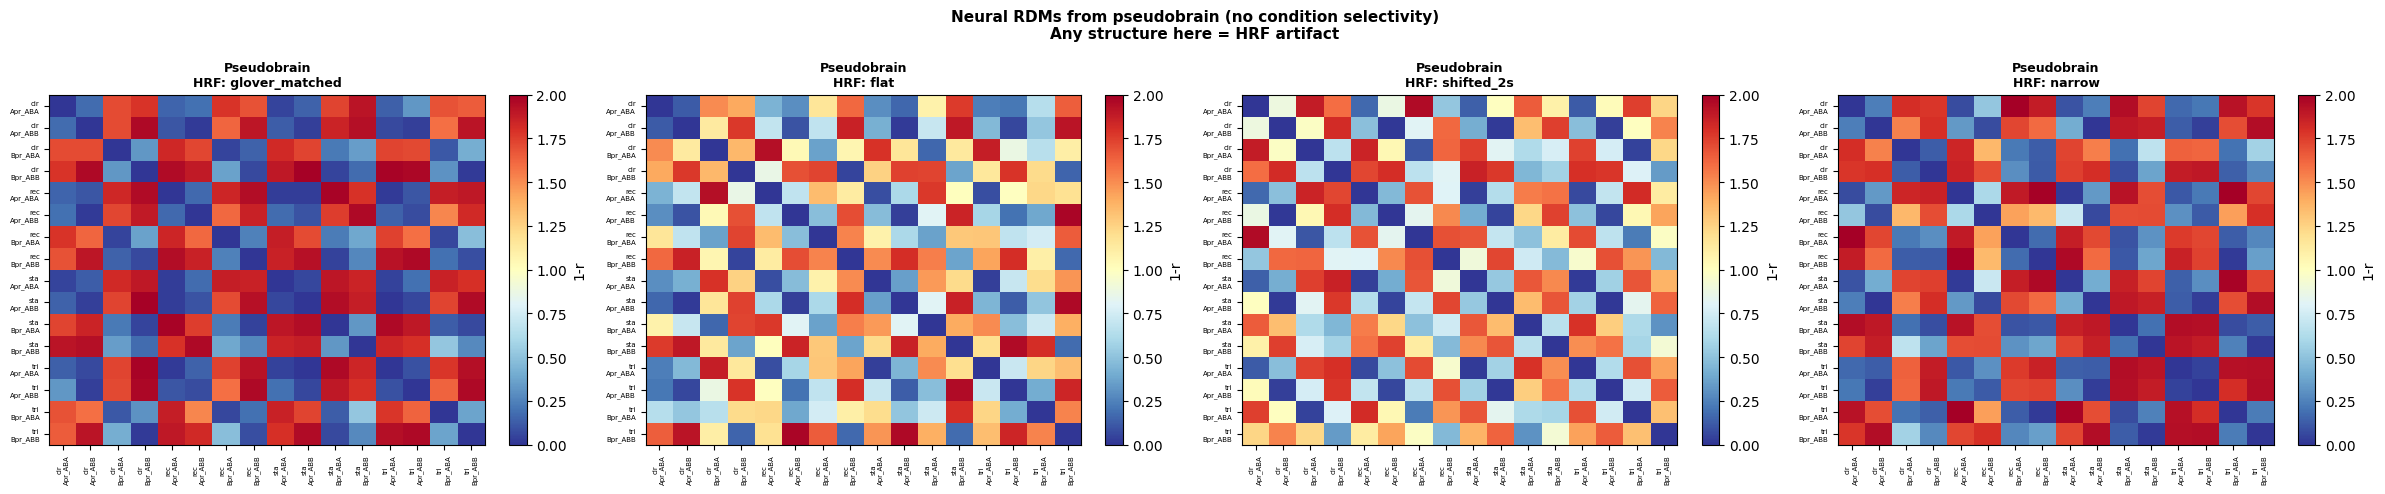

In [18]:

# ── 8. Plot RDMs for each HRF condition ──────────────────────────────────────
short_labels = []
for c in test_conditions:
    p = parse_condition(c)
    rule = f"_{p['rule_type']}" if p['rule_type'] else ''
    short_labels.append(f"{p['shape'][:3]}\n{p['role'][:3]}{rule}")

fig, axes = plt.subplots(1, len(hrfs), figsize=(6 * len(hrfs), 5))
for ax, (hrf_name, rdm) in zip(axes, rdms.items()):
    im = ax.imshow(rdm, cmap='RdYlBu_r', vmin=0, vmax=2,
                   interpolation='none', aspect='auto')
    ax.set_xticks(range(n_test))
    ax.set_xticklabels(short_labels, fontsize=5, rotation=90)
    ax.set_yticks(range(n_test))
    ax.set_yticklabels(short_labels, fontsize=5)
    ax.set_title(f'Pseudobrain\nHRF: {hrf_name}', fontsize=9, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, label='1-r')

plt.suptitle('Neural RDMs from pseudobrain (no condition selectivity)\n'
             'Any structure here = HRF artifact',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'pseudobrain_rdms.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── 9. Compare pseudobrain RDM structure to model RDMs ───────────────────────
# If HRF artifact is driving real results, pseudobrain RDM should
# correlate with abstract role model RDM

from scipy.stats import spearmanr

npz        = np.load(os.path.join(results_dir, 'model_rdms_test.npz'), allow_pickle=True)
model_rdms_test = {k: npz[k] for k in npz.files if k != 'conditions'}

print(f"\nSpearman correlation: pseudobrain RDM vs model RDMs")
print(f"{'HRF':20s} {'shape':>10} {'abstract':>10} {'functional':>10}")
print("-" * 55)
for hrf_name, rdm in rdms.items():
    pseudo_vec = squareform(rdm)
    row = [hrf_name]
    for mname in ['shape_test', 'abstract_test', 'functional_test']:
        mvec = npz[mname]
        if mvec.ndim == 2:
            mvec = squareform(mvec)
        rho, _ = spearmanr(pseudo_vec, mvec)
        row.append(f"{rho:>10.3f}")
    print(f"{row[0]:20s} {row[1]} {row[2]} {row[3]}")


Spearman correlation: pseudobrain RDM vs model RDMs
HRF                       shape   abstract functional
-------------------------------------------------------
glover_matched           -0.160      0.864      0.127
flat                     -0.147      0.550      0.494
shifted_2s               -0.164      0.736      0.389
narrow                   -0.155      0.864      0.115


In [15]:
# Check the design matrix column correlations directly
dm = design_mats['glover_matched']

aprime_cols = [c for c in dm.columns if 'Aprime' in c]
bprime_cols = [c for c in dm.columns if 'Bprime' in c]

# Correlation between Aprime and Bprime regressors
from scipy.stats import pearsonr
for ac in aprime_cols[:2]:
    for bc in bprime_cols[:2]:
        r, _ = pearsonr(dm[ac], dm[bc])
        print(f"{ac:40s} vs {bc:40s}: r={r:.3f}")

# Also check Aprime vs Aprime (should be near zero — independent trials)
for i, ac1 in enumerate(aprime_cols[:2]):
    for ac2 in aprime_cols[i+1:3]:
        r, _ = pearsonr(dm[ac1], dm[ac2])
        print(f"{ac1:40s} vs {ac2:40s}: r={r:.3f}")

circle_Aprime_test1_ABA                  vs circle_Bprime_test2_ABA                 : r=-0.047
circle_Aprime_test1_ABA                  vs circle_Bprime_test2_ABB                 : r=-0.045
circle_Aprime_test1_ABB                  vs circle_Bprime_test2_ABA                 : r=-0.079
circle_Aprime_test1_ABB                  vs circle_Bprime_test2_ABB                 : r=-0.052
circle_Aprime_test1_ABA                  vs circle_Aprime_test1_ABB                 : r=-0.085
circle_Aprime_test1_ABA                  vs rectangle_Aprime_test1_ABA              : r=-0.021
circle_Aprime_test1_ABB                  vs rectangle_Aprime_test1_ABA              : r=-0.077


In [16]:
# Mask to within-position pairs only
from itertools import combinations

within_mask = np.array([
    parse_condition(c1)['phase'] == parse_condition(c2)['phase']
    for c1, c2 in combinations(test_conditions, 2)
])

print(f"Within-position pairs: {within_mask.sum()} / {len(within_mask)}")
# These are the only valid entries for your RSA

Within-position pairs: 56 / 120


In [19]:
# ── Check collinearity of condition regressors in design matrix ───────────────
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

# Get condition columns only — exclude confounds
dm = design_mats['glover_matched']
condition_cols = [c for c in dm.columns 
                  if not any(x in c for x in 
                             ['cosine', 'comp', 'trans', 'rot',
                              'csf', 'wm', 'global', 'constant', 'drift'])]
print(f"Condition columns: {len(condition_cols)}")
print(condition_cols)

Condition columns: 32
['circle_A_rule1', 'circle_A_rule3', 'circle_Aprime_test1_ABA', 'circle_Aprime_test1_ABB', 'circle_B_rule2', 'circle_B_rule3', 'circle_Bprime_test2_ABA', 'circle_Bprime_test2_ABB', 'rectangle_A_rule1', 'rectangle_A_rule3', 'rectangle_Aprime_test1_ABA', 'rectangle_Aprime_test1_ABB', 'rectangle_B_rule2', 'rectangle_B_rule3', 'rectangle_Bprime_test2_ABA', 'rectangle_Bprime_test2_ABB', 'star_A_rule1', 'star_A_rule3', 'star_Aprime_test1_ABA', 'star_Aprime_test1_ABB', 'star_B_rule2', 'star_B_rule3', 'star_Bprime_test2_ABA', 'star_Bprime_test2_ABB', 'triangle_A_rule1', 'triangle_A_rule3', 'triangle_Aprime_test1_ABA', 'triangle_Aprime_test1_ABB', 'triangle_B_rule2', 'triangle_B_rule3', 'triangle_Bprime_test2_ABA', 'triangle_Bprime_test2_ABB']


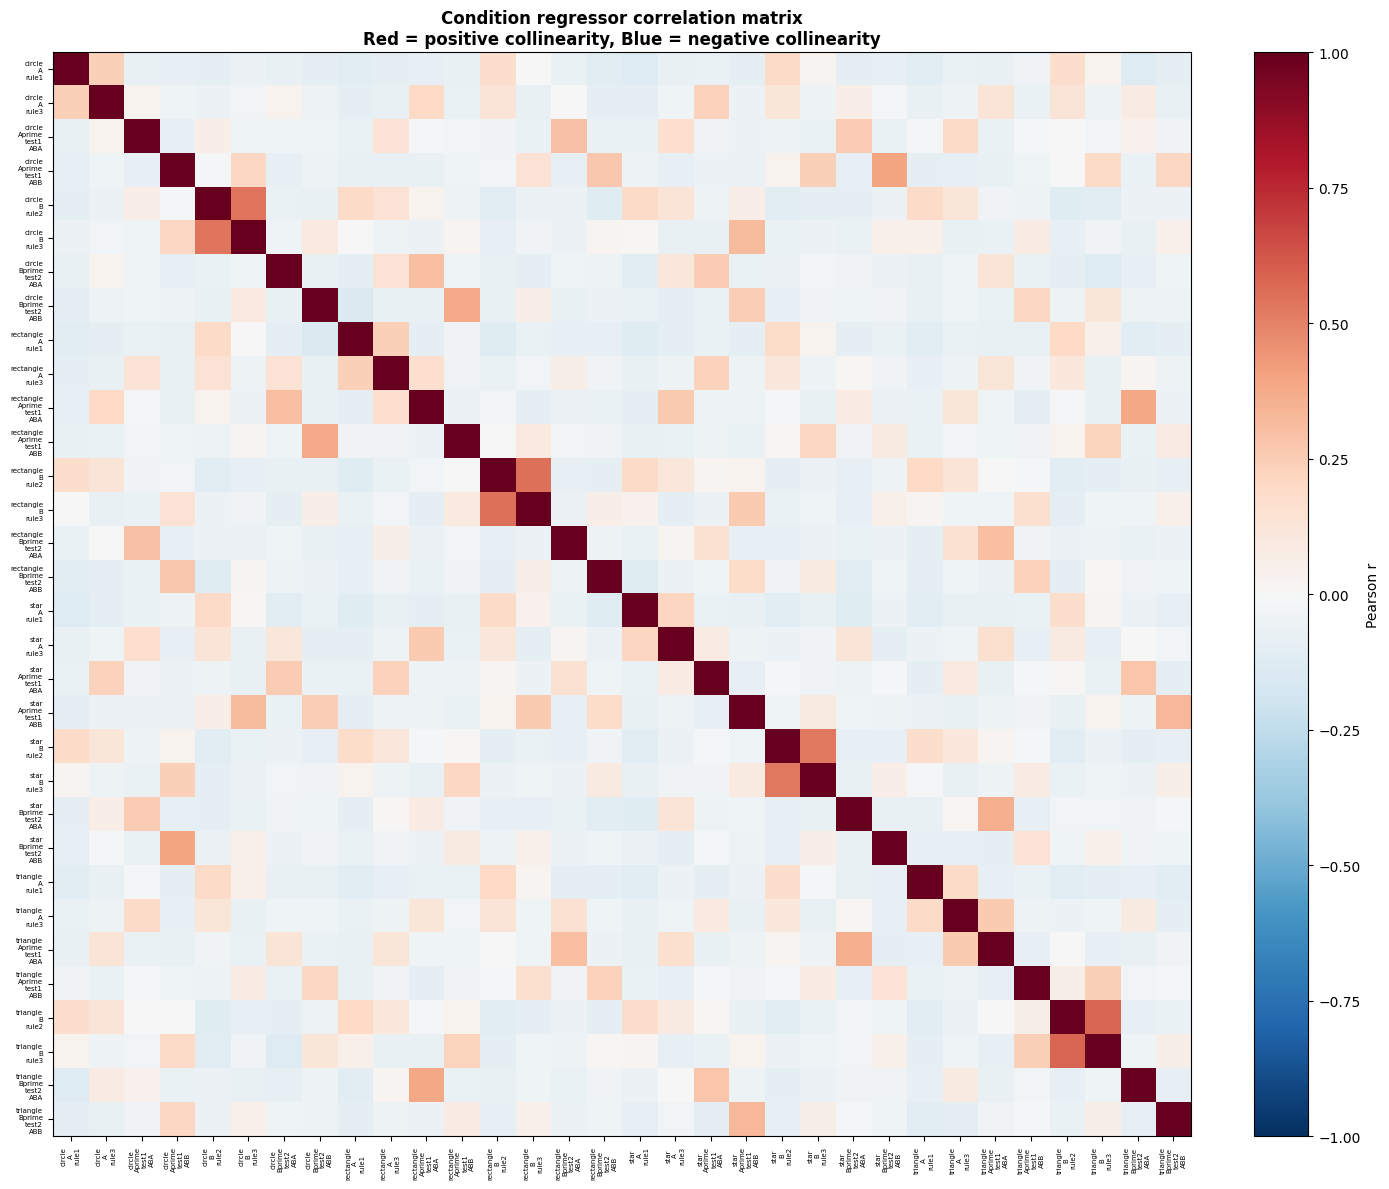

In [20]:
# ── Correlation matrix of condition regressors ────────────────────────────────
n_cols   = len(condition_cols)
corr_mat = np.zeros((n_cols, n_cols))

for i, c1 in enumerate(condition_cols):
    for j, c2 in enumerate(condition_cols):
        r, _ = pearsonr(dm[c1].values, dm[c2].values)
        corr_mat[i, j] = r

short_cols = [c.replace('_', '\n') for c in condition_cols]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr_mat, cmap='RdBu_r', vmin=-1, vmax=1,
               interpolation='none', aspect='auto')
ax.set_xticks(range(n_cols))
ax.set_xticklabels(short_cols, fontsize=5, rotation=90)
ax.set_yticks(range(n_cols))
ax.set_yticklabels(short_cols, fontsize=5)
ax.set_title('Condition regressor correlation matrix\n'
             'Red = positive collinearity, Blue = negative collinearity',
             fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046, label='Pearson r')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'regressor_collinearity.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# ── Flag highly collinear pairs ───────────────────────────────────────────────
print("\nHighly collinear pairs (|r| > 0.3):")
print(f"{'Col 1':40s} {'Col 2':40s} {'r':>8}")
print("-" * 92)
for i in range(n_cols):
    for j in range(i+1, n_cols):
        r = corr_mat[i, j]
        if abs(r) > 0.3:
            flag = ' ← SEVERE' if abs(r) > 0.7 else ''
            print(f"{condition_cols[i]:40s} {condition_cols[j]:40s} {r:>8.3f}{flag}")


Highly collinear pairs (|r| > 0.3):
Col 1                                    Col 2                                           r
--------------------------------------------------------------------------------------------
circle_Aprime_test1_ABB                  star_Bprime_test2_ABB                       0.396
circle_B_rule2                           circle_B_rule3                              0.537
circle_B_rule3                           star_Aprime_test1_ABB                       0.317
circle_Bprime_test2_ABB                  rectangle_Aprime_test1_ABB                  0.379
rectangle_Aprime_test1_ABA               triangle_Bprime_test2_ABA                   0.389
rectangle_B_rule2                        rectangle_B_rule3                           0.552
rectangle_Bprime_test2_ABA               triangle_Aprime_test1_ABA                   0.301
star_Aprime_test1_ABB                    triangle_Bprime_test2_ABB                   0.333
star_B_rule2                             star_B_rul

In [23]:
# ── Specifically check test1 vs test2 regressor correlations ─────────────────
# This is the key confound — same-position regressors should be highly correlated
# cross-position regressors should be anti-correlated

test1_cols = [c for c in condition_cols if 'test1' in c]
test2_cols = [c for c in condition_cols if 'test2' in c]

print(f"\nTest1 vs Test1 (same position — expect high positive r):")
for c1 in test1_cols:
    for c2 in test1_cols:
        if c1 < c2:
            r, _ = pearsonr(dm[c1].values, dm[c2].values)
            print(f"  {c1:35s} vs {c2:35s}: r={r:.3f}")

print(f"\nTest2 vs Test2 (same position — expect high positive r):")
for c1 in test2_cols:
    for c2 in test2_cols:
        if c1 < c2:
            r, _ = pearsonr(dm[c1].values, dm[c2].values)
            print(f"  {c1:35s} vs {c2:35s}: r={r:.3f}")

print(f"\nTest1 vs Test2 (cross position — expect negative r):")
for c1 in test1_cols[:3]:   # first 3 to keep output manageable
    for c2 in test2_cols[:3]:
        r, _ = pearsonr(dm[c1].values, dm[c2].values)
        print(f"  {c1:35s} vs {c2:35s}: r={r:.3f}")


Test1 vs Test1 (same position — expect high positive r):
  circle_Aprime_test1_ABA             vs circle_Aprime_test1_ABB            : r=-0.085
  circle_Aprime_test1_ABA             vs rectangle_Aprime_test1_ABA         : r=-0.021
  circle_Aprime_test1_ABA             vs rectangle_Aprime_test1_ABB         : r=-0.028
  circle_Aprime_test1_ABA             vs star_Aprime_test1_ABA              : r=-0.038
  circle_Aprime_test1_ABA             vs star_Aprime_test1_ABB              : r=-0.061
  circle_Aprime_test1_ABA             vs triangle_Aprime_test1_ABA          : r=-0.068
  circle_Aprime_test1_ABA             vs triangle_Aprime_test1_ABB          : r=-0.016
  circle_Aprime_test1_ABB             vs rectangle_Aprime_test1_ABA         : r=-0.077
  circle_Aprime_test1_ABB             vs rectangle_Aprime_test1_ABB         : r=-0.043
  circle_Aprime_test1_ABB             vs star_Aprime_test1_ABA              : r=-0.060
  circle_Aprime_test1_ABB             vs star_Aprime_test1_ABB          

In [24]:
# ── VIF for condition regressors ──────────────────────────────────────────────
# VIF > 5 = problematic, VIF > 10 = severe
from numpy.linalg import lstsq

X_cond = dm[condition_cols].values   # (n_trs, n_cond_cols)

print("\nVIF for condition regressors:")
vifs = {}
for k, name in enumerate(condition_cols):
    y_k    = X_cond[:, k]
    X_rest = np.delete(X_cond, k, axis=1)
    X_rest = np.hstack([X_rest, np.ones((len(X_rest), 1))])
    betas, _, _, _ = lstsq(X_rest, y_k, rcond=None)
    y_pred = X_rest @ betas
    ss_res = ((y_k - y_pred)**2).sum()
    ss_tot = ((y_k - y_k.mean())**2).sum()
    r2     = 1 - ss_res / ss_tot
    vif    = 1 / (1 - r2) if r2 < 1.0 else np.inf
    vifs[name] = vif
    flag = '  ← SEVERE' if vif > 10 else ('  ← WARNING' if vif > 5 else '')
    print(f"  {name:40s}: VIF={vif:.2f}{flag}")
    


VIF for condition regressors:
  circle_A_rule1                          : VIF=4.31
  circle_A_rule3                          : VIF=10.08  ← SEVERE
  circle_Aprime_test1_ABA                 : VIF=5.88  ← WARNING
  circle_Aprime_test1_ABB                 : VIF=10.59  ← SEVERE
  circle_B_rule2                          : VIF=11.87  ← SEVERE
  circle_B_rule3                          : VIF=10.07  ← SEVERE
  circle_Bprime_test2_ABA                 : VIF=3.70
  circle_Bprime_test2_ABB                 : VIF=4.01
  rectangle_A_rule1                       : VIF=4.72
  rectangle_A_rule3                       : VIF=9.67  ← WARNING
  rectangle_Aprime_test1_ABA              : VIF=9.31  ← WARNING
  rectangle_Aprime_test1_ABB              : VIF=6.28  ← WARNING
  rectangle_B_rule2                       : VIF=11.45  ← SEVERE
  rectangle_B_rule3                       : VIF=10.18  ← SEVERE
  rectangle_Bprime_test2_ABA              : VIF=3.64
  rectangle_Bprime_test2_ABB              : VIF=3.85
  star_A_ru

In [27]:
# ── LSS: one GLM per trial ────────────────────────────────────────────────────
def run_lss(bold_img, events_df, confounds, sample_mask, tr, n_trs):
    """
    Least Squares Separate: fit one GLM per trial.
    The trial of interest gets its own regressor.
    All other trials are collapsed into a single 'other' regressor.
    
    Returns: dict mapping condition_label -> list of beta maps (one per trial)
    """
    from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
    
    TR_array   = np.arange(n_trs) * tr
    trial_betas = {cond: [] for cond in events_df['trial_type'].unique()}
    
    mask = nib.Nifti1Image(
        np.ones(bold_img.shape[:3], dtype=np.int8), bold_img.affine
    )
    
    for trial_idx in range(len(events_df)):
        trial      = events_df.iloc[trial_idx]
        trial_type = trial['trial_type']
        
        # This trial gets its own regressor
        trial_event = events_df.iloc[[trial_idx]].copy()
        
        # All other trials collapsed into 'other'
        other_events = events_df.drop(index=trial_idx).copy()
        other_events['trial_type'] = 'other'
        
        # Combined events for this GLM
        lss_events = pd.concat([trial_event, other_events], 
                                ignore_index=True)
        
        design_matrix = make_first_level_design_matrix(
            TR_array, lss_events,
            hrf_model   = 'glover',
            drift_model = None,
            add_regs    = confounds
        )
        
        model = FirstLevelModel(
            t_r            = tr,
            hrf_model      = 'glover',
            mask_img       = mask,
            smoothing_fwhm = None,
            standardize    = 'zscore_sample',
            signal_scaling = False,
            drift_model    = None,
            minimize_memory= True    # critical — fitting many GLMs
        )
        model.fit([bold_img], 
                  design_matrices   = [design_matrix],
                  sample_masks      = [sample_mask])
        
        # Extract beta for this trial only
        beta_img = model.compute_contrast(
            trial_type, output_type='effect_size'
        )
        trial_betas[trial_type].append(beta_img)
        
        if trial_idx % 50 == 0:
            print(f"  Trial {trial_idx}/{len(events_df)}")
    
    return trial_betas

# ── Average trial betas within condition → condition beta maps ─────────────────
def average_lss_betas(trial_betas):
    """
    Average trial-level beta maps within each condition.
    Returns dict: condition -> mean beta NIfTI
    """
    from nilearn.image import mean_img
    
    condition_betas = {}
    for cond, beta_list in trial_betas.items():
        if len(beta_list) == 0:
            continue
        condition_betas[cond] = mean_img(beta_list)
        print(f"  {cond:40s}: {len(beta_list)} trials averaged")
    return condition_betas

Running LSS pseudobrain diagnostic ...


/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],


  Trial 0/600


/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be igno

  Trial 50/600


...

  Trial 500/600


/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be igno

  Trial 550/600


/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be ignored.
  model.fit([bold_img],
/tmp/ipykernel_2885064/3420027603.py:51: UserWarning: If design matrices are supplied, [drift_model, t_r] will be igno

  rectangle_A_rule1                       : 30 trials averaged
  star_B_rule2                            : 30 trials averaged
  rectangle_A_rule3                       : 15 trials averaged
  star_Aprime_test1_ABA                   : 15 trials averaged
  triangle_Bprime_test2_ABA               : 16 trials averaged
  circle_A_rule1                          : 30 trials averaged
  rectangle_B_rule2                       : 30 trials averaged
  rectangle_B_rule3                       : 15 trials averaged
  circle_Aprime_test1_ABB                 : 20 trials averaged
  triangle_Bprime_test2_ABB               : 14 trials averaged
  triangle_A_rule1                        : 30 trials averaged
  star_Aprime_test1_ABB                   : 18 trials averaged
  circle_Bprime_test2_ABB                 : 17 trials averaged
  star_A_rule1                            : 30 trials averaged
  star_A_rule3                            : 15 trials averaged
  rectangle_Bprime_test2_ABA              : 16 trials a

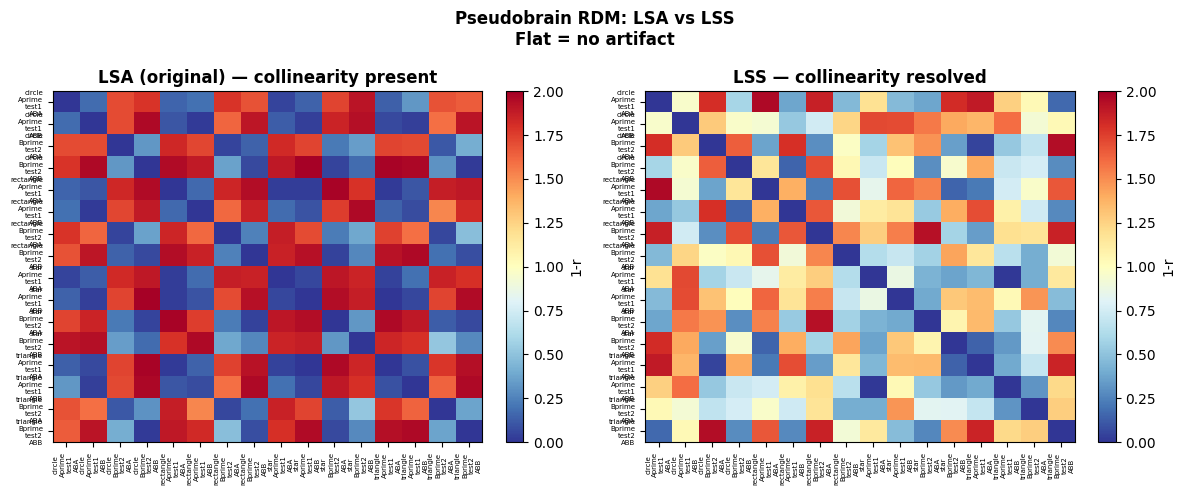

In [28]:
# ── Sanity check: rerun pseudobrain diagnostic with LSS ───────────────────────
# If LSS fixes the collinearity, the pseudobrain RDM should now be flat

def run_lss_pseudobrain(pseudo_nifti, real_events, n_trs, tr):
    """LSS on pseudobrain — should give flat RDM if collinearity was the issue."""
    trial_betas  = run_lss(pseudo_nifti, real_events, None, 
                           np.arange(n_trs), tr, n_trs)
    cond_betas   = average_lss_betas(trial_betas)
    
    test_conds   = [c for c in sorted(cond_betas.keys()) 
                    if 'test' in parse_condition(c)['phase']]
    betas        = np.array([cond_betas[c].get_fdata().reshape(-1) 
                             for c in test_conds])
    neural_rdm   = squareform(pdist(betas, metric='correlation'))
    return neural_rdm, test_conds

print("Running LSS pseudobrain diagnostic ...")
lss_rdm, test_conds = run_lss_pseudobrain(
    pseudo_niftis['glover_matched'], real_events, n_trs, TR
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
short = [c.replace('_','\n') for c in test_conds]

for ax, (rdm, title) in zip(axes, [
    (rdms['glover_matched'], 'LSA (original) — collinearity present'),
    (lss_rdm,               'LSS — collinearity resolved')
]):
    im = ax.imshow(rdm, cmap='RdYlBu_r', vmin=0, vmax=2,
                   interpolation='none', aspect='auto')
    ax.set_xticks(range(len(test_conds)))
    ax.set_xticklabels(short, fontsize=5, rotation=90)
    ax.set_yticks(range(len(test_conds)))
    ax.set_yticklabels(short, fontsize=5)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, label='1-r')

plt.suptitle('Pseudobrain RDM: LSA vs LSS\nFlat = no artifact', 
             fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'pseudobrain_lsa_vs_lss.png'), 
            dpi=150, bbox_inches='tight')
plt.show()